# Devoir 4
Rémi Aerts & Kélian Banco


### Imports

In [26]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit_aer.noise import NoiseModel, depolarizing_error
from matplotlib import pyplot as plt

### Question 1 :

In [5]:
#maj 
qc_maj = QuantumCircuit(3, name="MAJ")
qc_maj.cx(2,1)
qc_maj.cx(2,0)
qc_maj.ccx(0,1,2)


#uma
qc_uma = QuantumCircuit(3, name="UMA")
qc_uma.ccx(0,1,2)
qc_uma.cx(2,0)
qc_uma.cx(0,1)

print(f"MAJ Implementation : \n{qc_maj.draw(output='text')}\n")
print(f"UMA Implementation : \n{qc_uma.draw(output='text')}\n")

MAJ Implementation : 
          ┌───┐     
q_0: ─────┤ X ├──■──
     ┌───┐└─┬─┘  │  
q_1: ┤ X ├──┼────■──
     └─┬─┘  │  ┌─┴─┐
q_2: ──■────■──┤ X ├
               └───┘

UMA Implementation : 
          ┌───┐     
q_0: ──■──┤ X ├──■──
       │  └─┬─┘┌─┴─┐
q_1: ──■────┼──┤ X ├
     ┌─┴─┐  │  └───┘
q_2: ┤ X ├──■───────
     └───┘          



### Question 2

In [6]:
porte_maj = qc_maj.to_gate()
porte_uma = qc_uma.to_gate()

### Question 3

In [40]:
# Création des entrées et ligne de mesure
c0 = QuantumRegister(1, 'c0')
a = QuantumRegister(4, 'a')
b = QuantumRegister(4, 'b')
cout = QuantumRegister(1, 'c_out')
c_reg = ClassicalRegister(5, 'mesure')

def getQuantumAdditioner(option:str="none"):
    qc = QuantumCircuit(c0, a, b, cout, c_reg, name="Quantum Additionner")
    match option:
        case "arbitrary":
            qc.x(a[0])
            qc.x(a[2])

            qc.x(b[0])
            qc.x(b[1])
            qc.x(b[3])
        case "hadamard":
            for qubit in a:
                qc.h(qubit)
        case _ :
            pass
    
    # Ajout de délimitations entre les entrées et le circuit
    qc.barrier()
    
    # Ajout des différentes portes dans le circuit comme montré dans l'article
    qc.append(porte_maj, [c0[0], b[0], a[0]])
    qc.append(porte_maj, [a[0], b[1], a[1]])
    qc.append(porte_maj, [a[1], b[2], a[2]])
    qc.append(porte_maj, [a[2], b[3], a[3]])

    qc.cx(a[3], cout[0])

    qc.append(porte_uma, [a[2], b[3], a[3]])
    qc.append(porte_uma, [a[1], b[2], a[2]])
    qc.append(porte_uma, [a[0], b[1], a[1]])
    qc.append(porte_uma, [c0[0], b[0], a[0]])

    # Ajout de délimitations entre le circuit et les sorties
    qc.barrier()
    
    qc.measure(b, c_reg[0:4]) #résultat de la somme
    qc.measure(cout, c_reg[4])
    
    return qc
    

### Question 4

In [41]:
qc_with_arbitrary_values = getQuantumAdditioner("arbitrary")
print(qc_with_arbitrary_values.draw(output='text'))

                ░ ┌──────┐                                                     »
      c0: ──────░─┤0     ├─────────────────────────────────────────────────────»
          ┌───┐ ░ │      │┌──────┐                                     ┌──────┐»
     a_0: ┤ X ├─░─┤2     ├┤0     ├─────────────────────────────────────┤0     ├»
          └───┘ ░ │      ││      │┌──────┐                     ┌──────┐│      │»
     a_1: ──────░─┤      ├┤2     ├┤0     ├─────────────────────┤0     ├┤2     ├»
          ┌───┐ ░ │  MAJ ││      ││      │┌──────┐     ┌──────┐│      ││      │»
     a_2: ┤ X ├─░─┤      ├┤      ├┤2     ├┤0     ├─────┤0     ├┤2     ├┤      ├»
          └───┘ ░ │      ││  MAJ ││      ││      │     │      ││      ││  UMA │»
     a_3: ──────░─┤      ├┤      ├┤      ├┤2     ├──■──┤2     ├┤      ├┤      ├»
          ┌───┐ ░ │      ││      ││  MAJ ││      │  │  │      ││  UMA ││      │»
     b_0: ┤ X ├─░─┤1     ├┤      ├┤      ├┤      ├──┼──┤      ├┤      ├┤      ├»
          ├───┤ ░ └──────┘│ 

### Question 5

In [43]:
modele_bruit = NoiseModel()

erreur_1q = depolarizing_error(0.02, 1)  # Pour x, h
erreur_2q = depolarizing_error(0.05, 2)  # Pour cx
erreur_3q = depolarizing_error(0.10, 3)

modele_bruit.add_all_qubit_quantum_error(erreur_1q, ['x', 'h'])
modele_bruit.add_all_qubit_quantum_error(erreur_2q, ['cx'])
modele_bruit.add_all_qubit_quantum_error(erreur_3q, ['ccx'])

qc_clean = getQuantumAdditioner()

aer = AerSimulator()
compile = transpile(qc_clean, aer, basis_gates=modele_bruit.basis_gates)
job = aer.run(compile, shots=1000, noise_model=modele_bruit)
result = job.result()
counts = result.get_counts(compile)

### Question 6

{'00100': 60, '00000': 314, '01000': 51, '00111': 60, '11111': 18, '00101': 35, '01100': 14, '00110': 20, '00011': 61, '00010': 74, '01010': 12, '01011': 27, '01001': 19, '10111': 13, '10010': 3, '00001': 76, '10000': 23, '01111': 45, '10001': 8, '11001': 1, '10100': 4, '10011': 9, '11100': 4, '01110': 16, '10101': 4, '11010': 3, '01101': 10, '11110': 3, '11000': 5, '11101': 2, '10110': 4, '11011': 2}


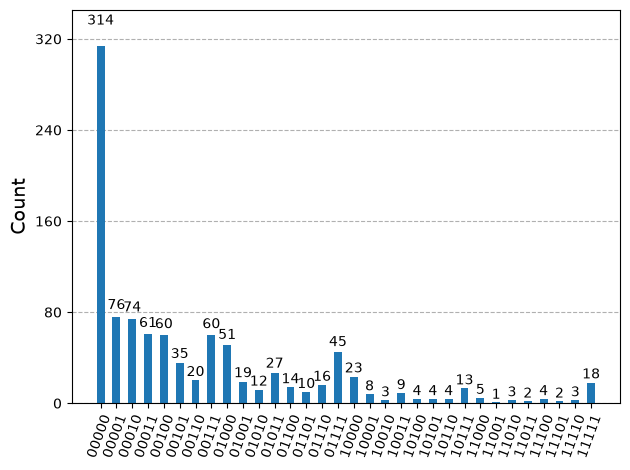

In [44]:
print(counts)

plot_histogram(counts)
# plt.show() # décommenter cette ligne si exécuté dans un fichier python

### Question 7

c:\Users\remia\Desktop\Cours\Informatique Quantique\8INF912_informatique_quantique\.venv\Lib\site-packages\qiskit\transpiler\preset_passmanagers\generate_preset_pass_manager.py:242: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  common_options = _parse_common_options(


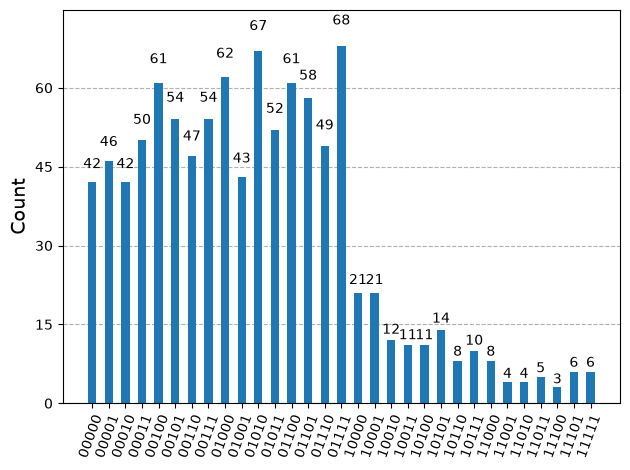

In [47]:
qc_hadamard = getQuantumAdditioner("hadamard")

aer = AerSimulator()
compile = transpile(qc_hadamard, aer, basis_gates=modele_bruit.basis_gates)
job = aer.run(compile, shots=1000, noise_model=modele_bruit)
result = job.result()
counts = result.get_counts(compile)
plot_histogram(counts)